# Projeto de Deep Learning: Classificação de Sons Ambientais e Comparação de Arquiteturas

Este notebook reúne o experimento original de *fine-tuning* de um **Audio Spectrogram Transformer (AST)** e a extensão para comparação com **Wav2Vec2**, **Whisper Encoder** e uma **CNN compacta** no dataset **ESC-50**, composto por 2.000 áudios de 5 segundos distribuídos em 50 classes.

O pipeline está organizado em nove etapas:

1. instalação/importação e reprodutibilidade;
2. carregamento e divisão oficial do ESC-50;
3. reamostragem para 16 kHz e extração de espectrogramas Log-Mel;
4. configuração do AST por *transfer learning*;
5. treinamento e avaliação;
6. inferência e visualização;
7. comparação entre arquiteturas;
8. robustez, calibração e explicabilidade;
9. consolidação dos resultados e roteiro para os slides.

> O AST já treinado é reutilizado por padrão. As células demoradas estão protegidas por chaves booleanas e não iniciam novos treinamentos durante a apresentação.


## Fundamentos teóricos

### 1. Forma de onda e taxa de amostragem

Para o computador, um áudio é um vetor de amplitudes. A taxa de amostragem informa quantas medições existem por segundo: em 16 kHz, cada segundo contém 16.000 valores. Todos os áudios devem usar a taxa esperada pelo modelo para que tempo e frequência sejam interpretados corretamente.

### 2. Do domínio do tempo ao domínio da frequência

A Transformada de Fourier separa o sinal em componentes de frequência. Aplicando filtros na escala Mel e o logaritmo da energia, obtemos o espectrograma Log-Mel: tempo no eixo X, frequência no eixo Y e intensidade representada pelas cores.

### 3. Audio Spectrogram Transformer

O AST divide o espectrograma em pequenos *patches*. Cada patch é convertido em um vetor e processado por camadas de autoatenção, que aprendem relações entre diferentes regiões de tempo e frequência. Neste projeto, usamos *transfer learning*: os pesos aprendidos no AudioSet são reaproveitados e a camada final é adaptada para as 50 classes do ESC-50.


## 1. Instalação, importações e reprodutibilidade

No ambiente local, as dependências estão registradas em `requirements.txt` e instaladas na `.venv`. O FFmpeg é a dependência de sistema usada pelo TorchCodec para decodificar os áudios. Para recriar o ambiente no macOS, execute `python3.11 -m venv .venv`, `source .venv/bin/activate`, `pip install -r requirements.txt` e `brew install ffmpeg`.

O áudio é originalmente uma sequência unidimensional de amplitudes. O ESC-50 usa 44,1 kHz, mas o AST pré-treinado espera entradas em 16 kHz. A semente fixa torna a execução mais reproduzível.


In [1]:
from pathlib import Path
import random

import evaluate
import librosa
import librosa.display
import matplotlib.pyplot as plt
import numpy as np
import torch
import torchaudio

from datasets import Audio, DatasetDict, load_dataset
from sklearn.metrics import ConfusionMatrixDisplay, classification_report
from transformers import (
    ASTForAudioClassification,
    AutoConfig,
    AutoFeatureExtractor,
    Trainer,
    TrainingArguments,
)

SEED = 42
MODEL_ID = "MIT/ast-finetuned-audioset-10-10-0.4593"
NOTEBOOK_DIR = Path.cwd() if Path.cwd().name == "notebooks" else Path.cwd() / "notebooks"
OUTPUT_DIR = NOTEBOOK_DIR / "resultados_ast_esc50_corrigido"
FINAL_MODEL_DIR = NOTEBOOK_DIR / "modelo_ast_esc50_final_corrigido"

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    DEVICE = torch.device("cuda")
elif torch.backends.mps.is_available():
    DEVICE = torch.device("mps")
else:
    DEVICE = torch.device("cpu")

print("PyTorch:", torch.__version__)
print("Dispositivo:", DEVICE)


/Users/micael/Documents/GitHub/Deep-Learning/Projeto-Sons-Ambientes/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


PyTorch: 2.13.0
Dispositivo: mps


## 2. Carregamento e divisão oficial do ESC-50

O ESC-50 possui cinco *folds* oficiais e balanceados. Neste experimento, os folds 1–4 são usados para treino e o fold 5 para teste. Assim, cada classe possui 32 exemplos de treino e 8 de teste, evitando uma divisão aleatória fora do protocolo do dataset.


In [2]:
dataset_completo = load_dataset("ashraq/esc50")["train"]

print(dataset_completo)
print("Colunas:", dataset_completo.column_names)
print("Quantidade de classes:", len(set(dataset_completo["target"])))


Repo card metadata block was not found. Setting CardData to empty.


Dataset({
    features: ['filename', 'fold', 'target', 'category', 'esc10', 'src_file', 'take', 'audio'],
    num_rows: 2000
})
Colunas: ['filename', 'fold', 'target', 'category', 'esc10', 'src_file', 'take', 'audio']
Quantidade de classes: 50


### Reamostragem correta para 16 kHz

A coluna de áudio é convertida com `Audio(sampling_rate=16000)`. Isso altera cada clipe de 220.500 amostras em 44,1 kHz para aproximadamente 80.000 amostras em 16 kHz, preservando seus 5 segundos.


In [3]:
feature_extractor = AutoFeatureExtractor.from_pretrained(MODEL_ID)

dataset_completo = dataset_completo.cast_column(
    "audio",
    Audio(sampling_rate=feature_extractor.sampling_rate),
)

dataset = DatasetDict({
    "train": dataset_completo.filter(
        lambda exemplo: exemplo["fold"] != 5,
        desc="Separando folds 1-4 para treino",
    ),
    "test": dataset_completo.filter(
        lambda exemplo: exemplo["fold"] == 5,
        desc="Separando fold 5 para teste",
    ),
})

audio_verificacao = dataset["train"][0]["audio"]
assert audio_verificacao["sampling_rate"] == feature_extractor.sampling_rate
assert len(audio_verificacao["array"]) == 5 * feature_extractor.sampling_rate

print(dataset)
print("Taxa após reamostragem:", audio_verificacao["sampling_rate"], "Hz")
print("Amostras em 5 segundos:", len(audio_verificacao["array"]))


Separando fold 5 para teste: 100%|██████████| 2000/2000 [00:20<00:00, 99.95 examples/s] 

DatasetDict({
    train: Dataset({
        features: ['filename', 'fold', 'target', 'category', 'esc10', 'src_file', 'take', 'audio'],
        num_rows: 1600
    })
    test: Dataset({
        features: ['filename', 'fold', 'target', 'category', 'esc10', 'src_file', 'take', 'audio'],
        num_rows: 400
    })
})
Taxa após reamostragem: 16000 Hz
Amostras em 5 segundos: 80000


### Classes e balanceamento

O mapeamento entre identificadores numéricos e nomes será salvo na configuração do modelo. Isso permite transformar diretamente a saída numérica do AST em uma categoria legível.


In [4]:
pares_unicos = set(zip(dataset["train"]["target"], dataset["train"]["category"]))
pares_ordenados = sorted(pares_unicos, key=lambda par: par[0])

labels = [categoria for _, categoria in pares_ordenados]
num_labels = len(labels)
label2id = {label: indice for indice, label in enumerate(labels)}
id2label = {indice: label for indice, label in enumerate(labels)}

assert num_labels == 50

contagens_treino = np.bincount(dataset["train"]["target"], minlength=num_labels)
contagens_teste = np.bincount(dataset["test"]["target"], minlength=num_labels)

print("Classes:", num_labels)
print("Exemplos por classe no treino:", np.unique(contagens_treino))
print("Exemplos por classe no teste:", np.unique(contagens_teste))
print(pares_ordenados)


Classes: 50
Exemplos por classe no treino: [32]
Exemplos por classe no teste: [8]
[(0, 'dog'), (1, 'rooster'), (2, 'pig'), (3, 'cow'), (4, 'frog'), (5, 'cat'), (6, 'hen'), (7, 'insects'), (8, 'sheep'), (9, 'crow'), (10, 'rain'), (11, 'sea_waves'), (12, 'crackling_fire'), (13, 'crickets'), (14, 'chirping_birds'), (15, 'water_drops'), (16, 'wind'), (17, 'pouring_water'), (18, 'toilet_flush'), (19, 'thunderstorm'), (20, 'crying_baby'), (21, 'sneezing'), (22, 'clapping'), (23, 'breathing'), (24, 'coughing'), (25, 'footsteps'), (26, 'laughing'), (27, 'brushing_teeth'), (28, 'snoring'), (29, 'drinking_sipping'), (30, 'door_wood_knock'), (31, 'mouse_click'), (32, 'keyboard_typing'), (33, 'door_wood_creaks'), (34, 'can_opening'), (35, 'washing_machine'), (36, 'vacuum_cleaner'), (37, 'clock_alarm'), (38, 'clock_tick'), (39, 'glass_breaking'), (40, 'helicopter'), (41, 'chainsaw'), (42, 'siren'), (43, 'car_horn'), (44, 'engine'), (45, 'train'), (46, 'church_bells'), (47, 'airplane'), (48, 'firewo

## 3. Pré-processamento com o Feature Extractor

O `AutoFeatureExtractor` converte os vetores de áudio, já reamostrados para 16 kHz, em bancos de filtros Log-Mel. O AST usa esses valores como uma representação bidimensional de tempo e frequência.

O comprimento padrão de 1.024 frames do modelo é mantido. Como os áudios possuem 5 segundos, o extrator preenche o restante da entrada com zeros.


In [5]:
def preprocess_function(exemplos):
    audio_arrays = [
        np.asarray(audio["array"], dtype=np.float32)
        for audio in exemplos["audio"]
    ]

    return feature_extractor(
        audio_arrays,
        sampling_rate=feature_extractor.sampling_rate,
    )


colunas_para_remover = [
    coluna
    for coluna in dataset["train"].column_names
    if coluna != "target"
]

encoded_dataset = dataset.map(
    preprocess_function,
    batched=True,
    batch_size=16,
    remove_columns=colunas_para_remover,
    desc="Extraindo espectrogramas Log-Mel",
)

encoded_dataset = encoded_dataset.rename_column("target", "labels")
encoded_dataset.set_format("torch")

print(encoded_dataset)
print("Formato de uma entrada:", tuple(encoded_dataset["train"][0]["input_values"].shape))


Extraindo espectrogramas Log-Mel: 100%|██████████| 400/400 [00:05<00:00, 76.04 examples/s]

DatasetDict({
    train: Dataset({
        features: ['labels', 'input_values'],
        num_rows: 1600
    })
    test: Dataset({
        features: ['labels', 'input_values'],
        num_rows: 400
    })
})
Formato de uma entrada: (1024, 128)


## 4. Configuração do AST por Transfer Learning

O modelo parte de pesos treinados no AudioSet. A cabeça de classificação original é substituída por uma nova camada com 50 saídas, uma para cada categoria do ESC-50.


In [6]:
config = AutoConfig.from_pretrained(
    MODEL_ID,
    num_labels=num_labels,
    label2id=label2id,
    id2label=id2label,
)

model = ASTForAudioClassification.from_pretrained(
    MODEL_ID,
    config=config,
    ignore_mismatched_sizes=True,
)

parametros_totais = sum(parametro.numel() for parametro in model.parameters())
parametros_treinaveis = sum(
    parametro.numel()
    for parametro in model.parameters()
    if parametro.requires_grad
)

print("Modelo configurado com sucesso!")
print(f"Parâmetros totais: {parametros_totais:,}")
print(f"Parâmetros treináveis: {parametros_treinaveis:,}")


[transformers] You passed `num_labels=50` which is incompatible to the `id2label` map of length `527`.
Loading weights: 100%|██████████| 203/203 [00:00<00:00, 10612.27it/s]
[transformers] ASTForAudioClassification LOAD REPORT from: MIT/ast-finetuned-audioset-10-10-0.4593
Key                     | Status   |                                                                                          
------------------------+----------+------------------------------------------------------------------------------------------
classifier.dense.weight | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([527, 768]) vs model:torch.Size([50, 768])
classifier.dense.bias   | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([527]) vs model:torch.Size([50])          

Notes:
- MISMATCH:	ckpt weights were loaded, but they did not match the original empty weight shapes.


Modelo configurado com sucesso!
Parâmetros totais: 86,227,250
Parâmetros treináveis: 86,227,250


## 5. Fine-tuning e avaliação

A acurácia mede a proporção total de previsões corretas. O F1 macro calcula o F1 de cada classe e depois tira a média, dando o mesmo peso às 50 categorias.


In [7]:
accuracy_metric = evaluate.load("accuracy")


def compute_metrics(eval_pred):
    predictions = np.argmax(eval_pred.predictions, axis=1)
    accuracy = accuracy_metric.compute(
        predictions=predictions,
        references=eval_pred.label_ids,
    )["accuracy"]

    relatorio = classification_report(
        eval_pred.label_ids,
        predictions,
        output_dict=True,
        zero_division=0,
    )

    return {
        "accuracy": accuracy,
        "f1_macro": relatorio["macro avg"]["f1-score"],
    }


### Treinamento

O treinamento original demorou aproximadamente 65 minutos no Mac e salvou o melhor modelo em `modelo_ast_esc50_final_corrigido`. A saída mantida abaixo documenta essa execução histórica.

> Como o checkpoint já existe, `TREINAR_AST_NOVAMENTE=False` faz esta célula apenas carregá-lo e reconstruir o `Trainer`. O fine-tuning só será repetido se essa chave for alterada manualmente para `True`.


In [8]:
TREINAR_AST_NOVAMENTE = False  # Mude para True somente se quiser refazer o fine-tuning.

training_args = TrainingArguments(
    output_dir=str(OUTPUT_DIR),
    eval_strategy="epoch",
    save_strategy="epoch",
    save_total_limit=1,
    learning_rate=3e-5,
    per_device_train_batch_size=4,
    per_device_eval_batch_size=4,
    gradient_accumulation_steps=4,
    num_train_epochs=3,
    warmup_steps=30,
    logging_steps=10,
    load_best_model_at_end=True,
    metric_for_best_model="accuracy",
    greater_is_better=True,
    seed=SEED,
    data_seed=SEED,
    dataloader_pin_memory=torch.cuda.is_available(),
    report_to="none",
)

if not TREINAR_AST_NOVAMENTE:
    if not FINAL_MODEL_DIR.exists():
        raise FileNotFoundError(
            f"Checkpoint não encontrado em {FINAL_MODEL_DIR}. "
            "Defina TREINAR_AST_NOVAMENTE=True para criar um novo."
        )
    model = ASTForAudioClassification.from_pretrained(FINAL_MODEL_DIR)
    print("Reutilizando o AST já treinado em:", FINAL_MODEL_DIR.resolve())

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=encoded_dataset["train"],
    eval_dataset=encoded_dataset["test"],
    processing_class=feature_extractor,
    compute_metrics=compute_metrics,
)

if TREINAR_AST_NOVAMENTE:
    print("Iniciando o treinamento...")
    resultado_treino = trainer.train()
    trainer.save_model(str(FINAL_MODEL_DIR))
    feature_extractor.save_pretrained(str(FINAL_MODEL_DIR))
    trainer.save_state()
    print(f"Treinamento concluído em {resultado_treino.metrics['train_runtime'] / 60:.1f} minutos.")
    print("Melhor checkpoint:", trainer.state.best_model_checkpoint)
    print("Modelo final salvo em:", FINAL_MODEL_DIR.resolve())
else:
    print("Treino ignorado: o checkpoint existente será usado na avaliação.")


Iniciando o treinamento...


Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro
1,0.336502,0.389601,0.915000,0.912361
2,0.031269,0.298812,0.917500,0.909785
3,0.007156,0.218269,0.927500,0.926422


Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  6.12it/s]
[transformers] There were missing keys in the checkpoint model loaded: ['audio_spectrogram_transformer.layers.0.attention.q_proj.weight', 'audio_spectrogram_transformer.layers.0.attention.q_proj.bias', 'audio_spectrogram_transformer.layers.0.attention.k_proj.weight', 'audio_spectrogram_transformer.layers.0.attention.k_proj.bias', 'audio_spectrogram_transformer.layers.0.attention.v_proj.weight', 'audio_spectrogram_transformer.layers.0.attention.v_proj.bias', 'audio_spectrogram_transformer.layers.0.attention.o_proj.weight', 'audio_spectrogram_transformer.layers.0.attention.o_proj.bias', 'audio_spectrogram_transformer.layers.0.layernorm_before.weight', 'audio_spectrogram_transformer.layers.0.layernorm_before.bias', 'audio_spectrogram_transformer.layers.0.layernorm_after.weight', 'audio_spectrogram_transformer.layers.0.layernorm_after.bias', 'audio_spectrogram_transformer.layers.0.mlp.fc1.weight', 'audio_spectrogram_transf

Treinamento concluído em 64.8 minutos.
Melhor checkpoint: resultados_ast_esc50_corrigido/checkpoint-300
Modelo final salvo em: /Users/micael/Documents/GitHub/Deep-Learning/Projeto-Sons-Ambientes/notebooks/modelo_ast_esc50_final_corrigido


### Avaliação final e matriz de confusão

A matriz de confusão normalizada mostra quais classes são confundidas entre si. A diagonal representa os acertos; valores fora dela indicam os principais erros do modelo.


Training Loss,Validation Loss,Epoch,Accuracy,F1 Macro
0.007156,0.218269,3,0.927500,0.926422


Métricas finais:
  eval_loss: 0.2183
  eval_accuracy: 0.9275
  eval_f1_macro: 0.9264



Relatório por classe:
                  precision    recall  f1-score   support

             dog      0.889     1.000     0.941         8
         rooster      1.000     1.000     1.000         8
             pig      1.000     0.625     0.769         8
             cow      1.000     0.875     0.933         8
            frog      1.000     0.875     0.933         8
             cat      0.800     1.000     0.889         8
             hen      0.800     1.000     0.889         8
         insects      0.875     0.875     0.875         8
           sheep      1.000     1.000     1.000         8
            crow      1.000     1.000     1.000         8
            rain      0.889     1.000     0.941         8
       sea_waves      1.000     0.875     0.933         8
  crackling_fire      1.000     0.750     0.857         8
        crickets      1.000     1.000     1.000         8
  chirping_birds      1.000     1.000     1.000         8
     water_drops      1.000     1.000     1.000 

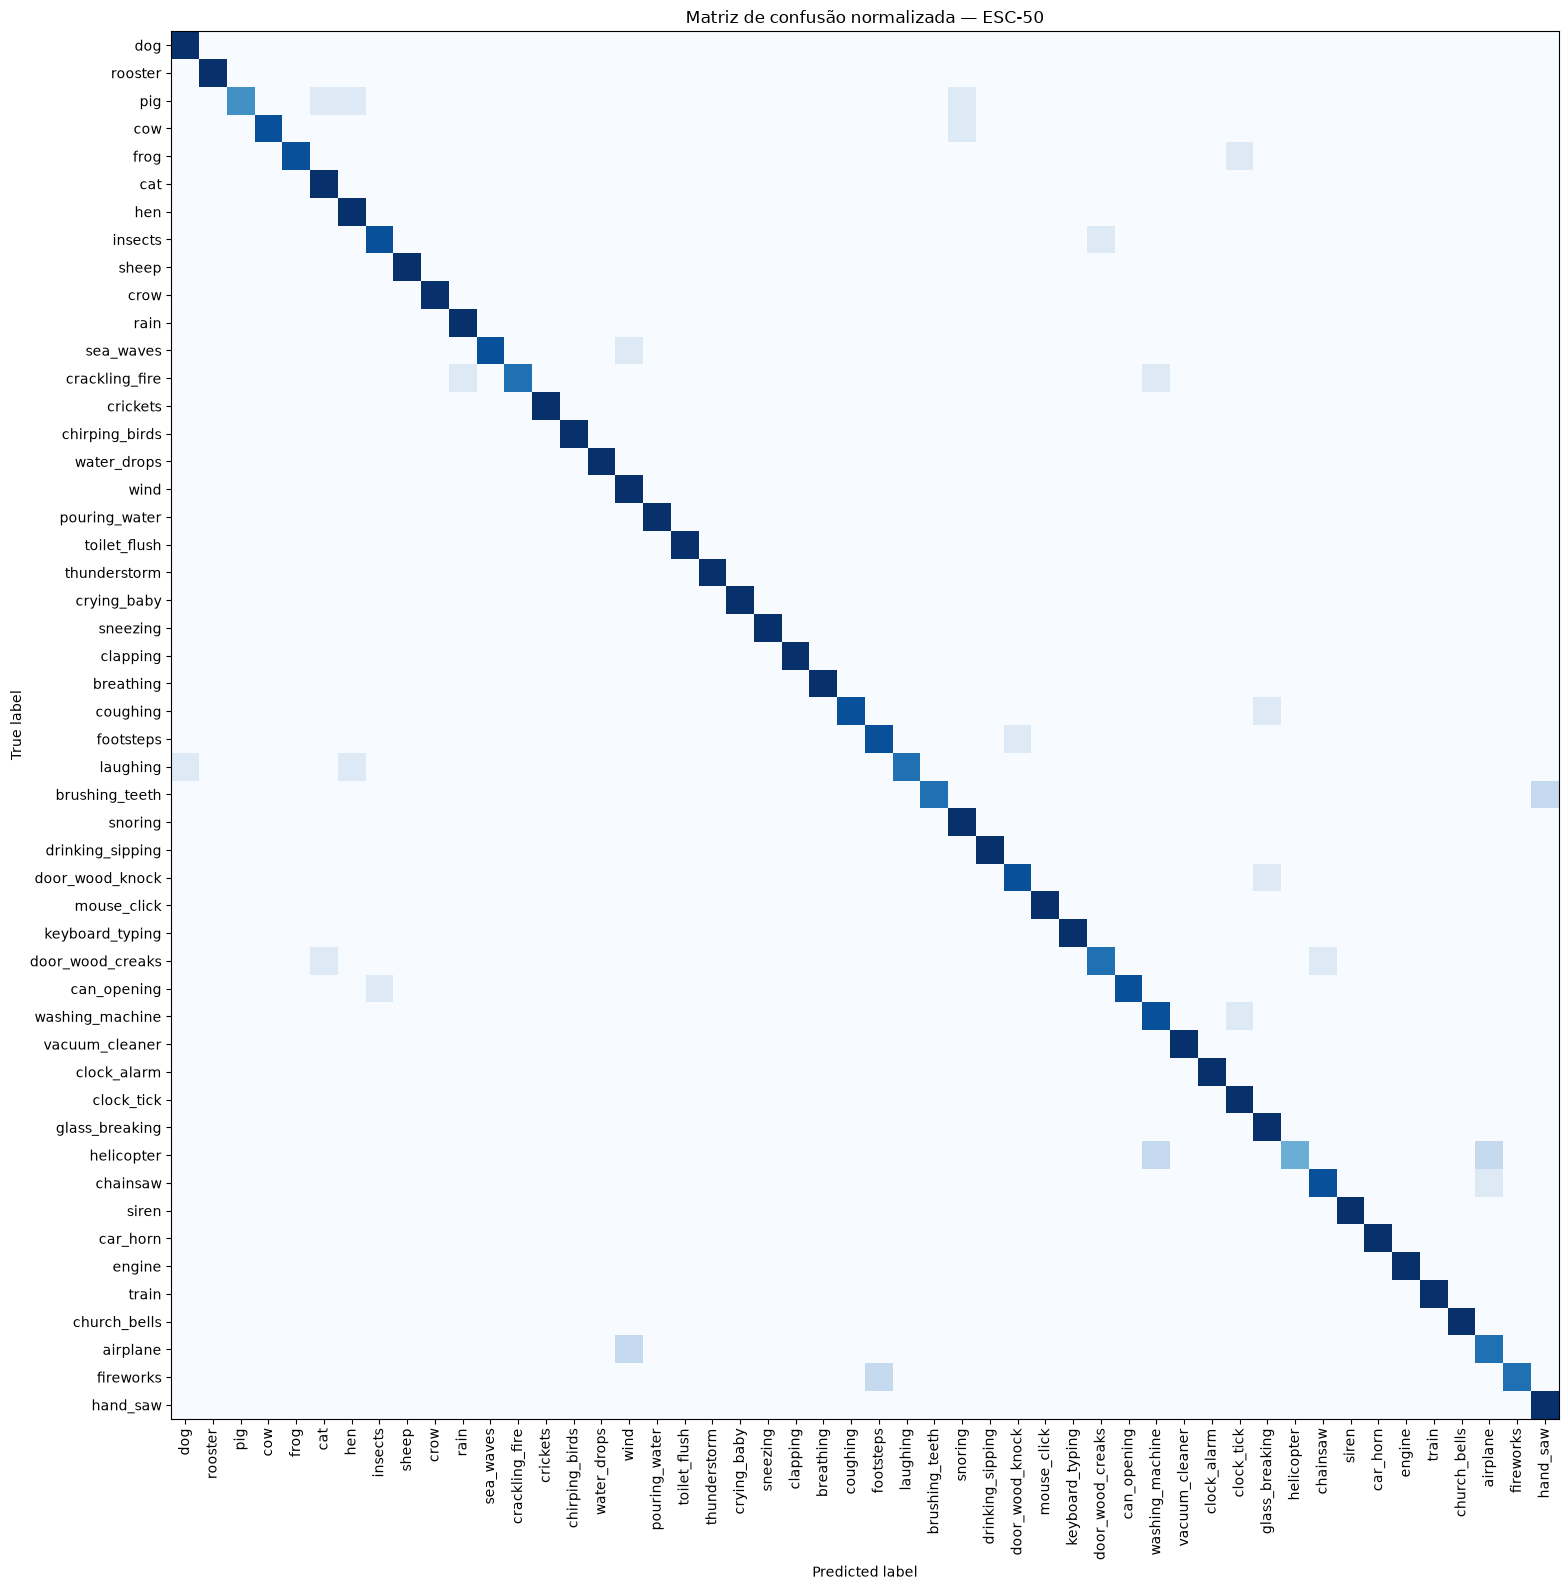

In [9]:
metricas_finais = trainer.evaluate()
print("Métricas finais:")
for nome, valor in metricas_finais.items():
    if isinstance(valor, float):
        print(f"  {nome}: {valor:.4f}")

resultado_predicoes = trainer.predict(encoded_dataset["test"])
y_true = resultado_predicoes.label_ids
y_pred = np.argmax(resultado_predicoes.predictions, axis=1)

print("\nRelatório por classe:")
print(
    classification_report(
        y_true,
        y_pred,
        labels=list(range(num_labels)),
        target_names=labels,
        digits=3,
        zero_division=0,
    )
)

fig, ax = plt.subplots(figsize=(18, 16))
ConfusionMatrixDisplay.from_predictions(
    y_true,
    y_pred,
    labels=list(range(num_labels)),
    display_labels=labels,
    normalize="true",
    include_values=False,
    xticks_rotation=90,
    cmap="Blues",
    ax=ax,
    colorbar=False,
)
ax.set_title("Matriz de confusão normalizada — ESC-50")
plt.tight_layout()
plt.show()


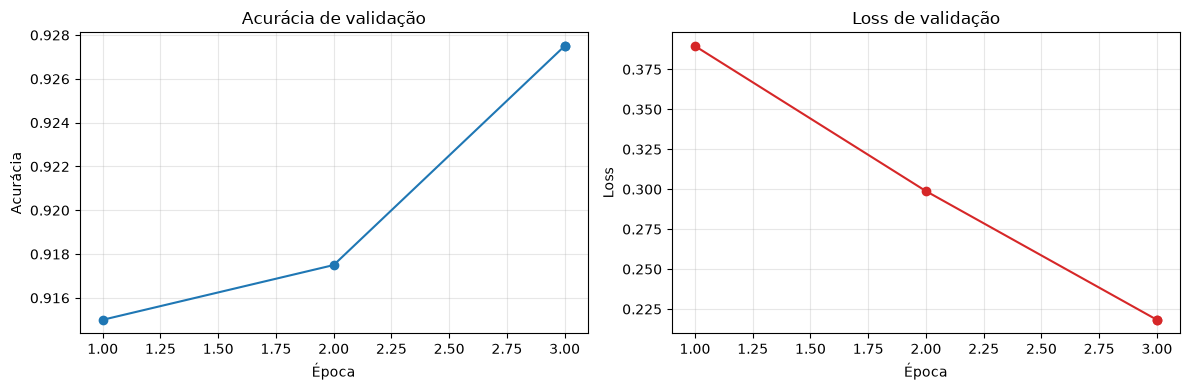

In [10]:
import json

if TREINAR_AST_NOVAMENTE:
    registros_treinamento = trainer.state.log_history
else:
    trainer_state_path = OUTPUT_DIR / "trainer_state.json"
    if not trainer_state_path.exists():
        raise FileNotFoundError(f"Histórico de treino não encontrado: {trainer_state_path}")
    registros_treinamento = json.loads(
        trainer_state_path.read_text(encoding="utf-8")
    )["log_history"]

historico_avaliacao = [
    registro
    for registro in registros_treinamento
    if "eval_accuracy" in registro and "epoch" in registro
]

epocas = [registro["epoch"] for registro in historico_avaliacao]
acuracias = [registro["eval_accuracy"] for registro in historico_avaliacao]
perdas = [registro["eval_loss"] for registro in historico_avaliacao]

fig, eixos = plt.subplots(1, 2, figsize=(12, 4))

eixos[0].plot(epocas, acuracias, marker="o")
eixos[0].set_title("Acurácia de validação")
eixos[0].set_xlabel("Época")
eixos[0].set_ylabel("Acurácia")
eixos[0].grid(alpha=0.3)

eixos[1].plot(epocas, perdas, marker="o", color="tab:red")
eixos[1].set_title("Loss de validação")
eixos[1].set_xlabel("Época")
eixos[1].set_ylabel("Loss")
eixos[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()


## Carregamento do modelo salvo

Em uma nova sessão, execute a célula de importações e esta célula. Não é necessário repetir o treinamento. Para avaliar novamente o dataset completo, também execute as etapas de carregamento e pré-processamento.


In [11]:
feature_extractor = AutoFeatureExtractor.from_pretrained(FINAL_MODEL_DIR)
model = ASTForAudioClassification.from_pretrained(FINAL_MODEL_DIR)
model.to(DEVICE)
model.eval()

print("Modelo carregado de:", FINAL_MODEL_DIR.resolve())


Loading weights: 100%|██████████| 203/203 [00:00<00:00, 10490.54it/s]


Modelo carregado de: /Users/micael/Documents/GitHub/Deep-Learning/Projeto-Sons-Ambientes/notebooks/modelo_ast_esc50_final_corrigido


## 6. Inferência e visualização

Primeiro, o modelo é testado em um exemplo do fold de teste. São mostradas a classe correta, a previsão e as cinco categorias mais prováveis.


In [12]:
def predict_audio(audio_array, sampling_rate, top_k=5):
    audio_array = np.asarray(audio_array, dtype=np.float32)

    if sampling_rate != feature_extractor.sampling_rate:
        audio_array = librosa.resample(
            audio_array,
            orig_sr=sampling_rate,
            target_sr=feature_extractor.sampling_rate,
        )
        sampling_rate = feature_extractor.sampling_rate

    inputs = feature_extractor(
        audio_array,
        sampling_rate=sampling_rate,
        return_tensors="pt",
    )
    inputs = {
        nome: tensor.to(DEVICE)
        for nome, tensor in inputs.items()
    }

    model.eval()
    with torch.no_grad():
        logits = model(**inputs).logits
        probabilidades = torch.softmax(logits, dim=-1)[0]

    valores, indices = torch.topk(probabilidades, k=top_k)

    return [
        {
            "classe_id": indice.item(),
            "classe": model.config.id2label[indice.item()],
            "probabilidade": valor.item(),
        }
        for valor, indice in zip(valores.cpu(), indices.cpu())
    ]


exemplo = dataset["test"][0]
audio_teste = exemplo["audio"]

previsoes = predict_audio(
    audio_teste["array"],
    audio_teste["sampling_rate"],
)

print("Classe correta:", exemplo["category"])
print("Classe prevista:", previsoes[0]["classe"])
print("\nTop 5 previsões:")
for previsao in previsoes:
    print(f"  {previsao['classe']:<25} {previsao['probabilidade']:.2%}")


Classe correta: pig
Classe prevista: pig

Top 5 previsões:
  pig                       81.97%
  sheep                     7.48%
  cow                       3.03%
  hen                       1.81%
  sneezing                  0.43%


### Espectrograma Log-Mel

O eixo horizontal representa o tempo, o eixo vertical representa as frequências na escala Mel e as cores representam a energia em decibéis. Esta visualização é conceitualmente equivalente à representação usada pelo AST; internamente, o extrator do modelo utiliza filtros Mel compatíveis com Kaldi.


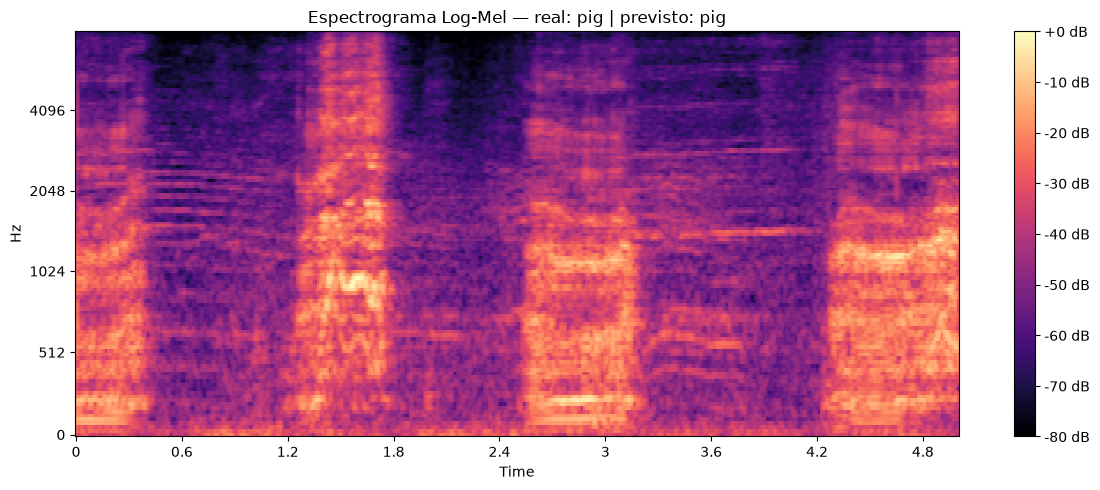

In [13]:
audio_array = np.asarray(audio_teste["array"], dtype=np.float32)
sampling_rate = audio_teste["sampling_rate"]

espectrograma_mel = librosa.feature.melspectrogram(
    y=audio_array,
    sr=sampling_rate,
    n_fft=1024,
    hop_length=160,
    n_mels=128,
)
espectrograma_db = librosa.power_to_db(
    espectrograma_mel,
    ref=np.max,
)

plt.figure(figsize=(12, 5))
librosa.display.specshow(
    espectrograma_db,
    sr=sampling_rate,
    hop_length=160,
    x_axis="time",
    y_axis="mel",
    cmap="magma",
)
plt.colorbar(format="%+2.0f dB")
plt.title(
    f"Espectrograma Log-Mel — real: {exemplo['category']} | "
    f"previsto: {previsoes[0]['classe']}"
)
plt.tight_layout()
plt.show()


### Teste com um áudio próprio

Coloque um arquivo WAV, MP3 ou FLAC na pasta `notebooks` e altere o nome abaixo. O `librosa.load(..., sr=16000)` realiza a reamostragem correta antes da inferência.


In [14]:
ARQUIVO_AUDIO = Path("./meu_audio.wav")

if ARQUIVO_AUDIO.exists():
    audio_proprio, sr_proprio = librosa.load(
        ARQUIVO_AUDIO,
        sr=feature_extractor.sampling_rate,
        mono=True,
    )
    previsoes_audio_proprio = predict_audio(audio_proprio, sr_proprio)

    print("Previsão:", previsoes_audio_proprio[0]["classe"])
    print("\nTop 5:")
    for previsao in previsoes_audio_proprio:
        print(f"  {previsao['classe']:<25} {previsao['probabilidade']:.2%}")
else:
    print(
        f"Arquivo não encontrado: {ARQUIVO_AUDIO}. "
        "Altere ARQUIVO_AUDIO para testar um som próprio."
    )


Arquivo não encontrado: meu_audio.wav. Altere ARQUIVO_AUDIO para testar um som próprio.


## 7. Extensão do projeto: comparação entre arquiteturas

A primeira parte deste notebook documentou e treinou a baseline AST. A partir daqui, o mesmo trabalho é ampliado para comparar diferentes representações de áudio. O código reutilizável está no pacote `esc50`, mas toda a execução e apresentação podem ser conduzidas por este notebook.

**O AST não será treinado novamente.** O checkpoint `modelo_ast_esc50_final_corrigido`, que atingiu 92,75% de acurácia e 92,64% de F1 macro, é reutilizado. As células de novos treinamentos começam desativadas e só executam quando a chave correspondente é alterada para `True`.


In [ ]:
import json
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

SEED = globals().get("SEED", 42)
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from esc50.data import read_metadata, validate_metadata
from esc50.experiment import cross_validate, screening
from esc50.inference import evaluate_robustness

ARTIFACTS_DIR = PROJECT_ROOT / "artifacts"
AST_SAVED_CHECKPOINT = PROJECT_ROOT / "notebooks/modelo_ast_esc50_final_corrigido"

EXECUTAR_TRIAGEM_NOVOS_MODELOS = False
EXECUTAR_VALIDACAO_CRUZADA = False
EXECUTAR_ROBUSTEZ_AST = False

assert AST_SAVED_CHECKPOINT.exists(), f"Checkpoint AST ausente: {AST_SAVED_CHECKPOINT}"
print("Raiz do projeto:", PROJECT_ROOT.resolve())
print("AST existente:", AST_SAVED_CHECKPOINT.resolve())
print("Treinos novos habilitados:", EXECUTAR_TRIAGEM_NOVOS_MODELOS)


### Arquiteturas comparadas

A comparação cobre quatro estratégias complementares. O AST trabalha com patches de espectrograma e possui pré-treinamento diretamente relacionado a eventos acústicos. O Wav2Vec2 recebe a forma de onda e aprende representações auto-supervisionadas. O Whisper pertence a uma arquitetura encoder-decoder, mas somente o encoder é utilizado para classificação. A CNN recebe Log-Mel e oferece uma referência pequena, rápida e sem Transformer.


In [ ]:
arquiteturas = pd.DataFrame([
    {"modelo": "AST", "entrada": "Log-Mel em patches", "pre_treinamento": "AudioSet", "papel": "Baseline já treinada"},
    {"modelo": "Wav2Vec2 Base", "entrada": "Forma de onda", "pre_treinamento": "Fala auto-supervisionada", "papel": "Encoder temporal"},
    {"modelo": "Whisper Tiny", "entrada": "Log-Mel", "pre_treinamento": "Reconhecimento de fala", "papel": "Encoder de uma rede encoder-decoder"},
    {"modelo": "CNN compacta", "entrada": "Log-Mel", "pre_treinamento": "Nenhum", "papel": "Baseline leve"},
])
display(arquiteturas)


### Protocolo sem vazamento entre treino, validação e teste

O resultado AST existente é preservado como **referência histórica**: ele foi treinado nos folds 1–4 e o fold 5 foi avaliado a cada época. Para os novos modelos, a triagem metodologicamente controlada usa folds 1–3 para treino, fold 4 para seleção da época e fold 5 apenas para teste cego. Os dois melhores modelos novos podem depois passar pelos cinco folds oficiais.

Essa distinção deve aparecer nos slides: os 92,75% do AST são um resultado válido do experimento original, mas não devem ser apresentados como comparação estritamente equivalente ao novo teste cego.


In [ ]:
metadata_esc50 = read_metadata(PROJECT_ROOT / "data/esc50.csv")
validate_metadata(metadata_esc50)

contagem_por_fold = (
    metadata_esc50.groupby("fold")
    .agg(exemplos=("filename", "count"), classes=("target", "nunique"))
    .reset_index()
)
protocolo = pd.DataFrame([
    {"etapa": "Treino", "folds": "1, 2 e 3", "exemplos_por_classe": 24},
    {"etapa": "Validação", "folds": "4", "exemplos_por_classe": 8},
    {"etapa": "Teste cego", "folds": "5", "exemplos_por_classe": 8},
])
display(contagem_por_fold)
display(protocolo)


### Triagem opcional dos novos modelos

A célula abaixo treina apenas Wav2Vec2, Whisper e CNN. O AST salvo não é tocado. Cada execução registra checkpoint, melhor época, métricas, parâmetros, tamanho, tempo e latência. Para evitar um treino acidental durante a apresentação, `EXECUTAR_TRIAGEM_NOVOS_MODELOS` começa como `False`.


In [ ]:
if EXECUTAR_TRIAGEM_NOVOS_MODELOS:
    resumo_triagem = screening(
        models=("wav2vec2", "whisper", "cnn"),
        output_root=ARTIFACTS_DIR / "screening",
        seed=SEED,
        epochs=10,
    )
    display(resumo_triagem)
else:
    print("Triagem não executada. Mude EXECUTAR_TRIAGEM_NOVOS_MODELOS para True quando houver tempo para os treinos.")


### Tabela consolidada de resultados

Esta tabela sempre inclui o AST já treinado. Se a triagem dos outros modelos já tiver sido executada, os resultados são incorporados automaticamente. A coluna `protocolo` impede que uma referência histórica seja confundida com o teste cego.


In [ ]:
historico_path = PROJECT_ROOT / "configs/historical_baseline.json"
historico_ast = json.loads(historico_path.read_text(encoding="utf-8"))

linhas_resultados = [{
    "modelo": "AST",
    "protocolo": "Referência histórica — folds 1–4 / fold 5 monitorado",
    "acuracia": historico_ast["accuracy"],
    "f1_macro": historico_ast["f1_macro"],
    "melhor_epoca": historico_ast["epochs"],
    "status": "Concluído; checkpoint reutilizado",
}]

screening_path = ARTIFACTS_DIR / "screening/summary.csv"
if screening_path.exists():
    resultados_novos = pd.read_csv(screening_path)
    for _, registro in resultados_novos.iterrows():
        linhas_resultados.append({
            "modelo": registro["model_family"],
            "protocolo": "Triagem controlada — treino 1–3 / validação 4 / teste cego 5",
            "acuracia": registro.get("test_accuracy"),
            "f1_macro": registro.get("test_f1_macro"),
            "melhor_epoca": registro.get("best_epoch"),
            "status": "Triagem concluída",
        })

tabela_resultados = pd.DataFrame(linhas_resultados)
display(tabela_resultados.style.format({"acuracia": "{:.2%}", "f1_macro": "{:.2%}"}))

fig, ax = plt.subplots(figsize=(9, 4))
ax.bar(tabela_resultados["modelo"], tabela_resultados["f1_macro"], color="tab:blue")
ax.set_ylim(0, 1)
ax.set_ylabel("F1 macro")
ax.set_title("Resultados disponíveis — observar diferenças de protocolo")
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()


### Validação cruzada opcional

Depois da triagem, os dois melhores modelos novos são escolhidos pelo F1 macro de validação. O número de épocas fica congelado e cada modelo é treinado cinco vezes, alternando o fold de teste. Isso produz média e desvio-padrão. O AST antigo continua fora dessa etapa para evitar repetir seu treinamento; portanto, permanece identificado apenas como baseline histórica.


In [ ]:
if EXECUTAR_VALIDACAO_CRUZADA:
    if not screening_path.exists():
        raise FileNotFoundError("Execute a triagem antes da validação cruzada.")
    resultados_novos = pd.read_csv(screening_path).sort_values("validation_f1_macro", ascending=False)
    finalistas = tuple(resultados_novos.head(2)["model_family"])
    epocas_finalistas = {
        registro["model_family"]: max(1, int(round(registro["best_epoch"])))
        for _, registro in resultados_novos.head(2).iterrows()
    }
    resumo_cv = cross_validate(
        models=finalistas,
        output_root=ARTIFACTS_DIR / "cross_validation",
        seed=SEED,
        epochs_by_model=epocas_finalistas,
    )
    display(resumo_cv)
else:
    print("Validação cruzada não executada. Ela só deve ser habilitada depois da triagem.")


## 8. Diferenciais: robustez, confiança e explicabilidade

O pipeline também mede o comportamento sob deslocamento temporal de ±0,5 s, ganho de ±6 dB e ruído em 20, 10 e 0 dB de SNR. A calibração verifica se a confiança declarada corresponde à frequência real de acertos. A oclusão temporal silencia janelas de 0,5 s para localizar quais trechos sustentam a decisão.

A robustez do AST pode ser avaliada diretamente no checkpoint existente, sem qualquer treinamento.


In [ ]:
if EXECUTAR_ROBUSTEZ_AST:
    evaluate_robustness(
        checkpoint=AST_SAVED_CHECKPOINT,
        test_fold=5,
        output_dir=ARTIFACTS_DIR / "robustness/ast-fold5",
        batch_size=4,
        seed=SEED,
    )
else:
    print("Robustez não executada. Mude EXECUTAR_ROBUSTEZ_AST para True; essa avaliação reutiliza o AST salvo.")


## 9. Roteiro recomendado para os slides

1. **Problema:** classificar 2.000 áudios ambientais em 50 categorias.
2. **Representação:** explicar forma de onda, Log-Mel e patches do AST.
3. **Baseline:** apresentar o AST pré-treinado no AudioSet e seu fine-tuning.
4. **Resultado já obtido:** 92,75% de acurácia e 92,64% de F1 macro no fold 5.
5. **Comparação proposta:** AST, Wav2Vec2, Whisper Encoder e CNN.
6. **Rigor metodológico:** separar treino, validação e teste cego; depois usar cinco folds.
7. **Métricas:** destacar F1 macro, matriz de confusão, calibração, latência e tamanho.
8. **Diferenciais:** robustez a ruído, augmentação e explicabilidade por oclusão.
9. **Limitação:** o AST histórico monitorou o fold 5 durante o treino e não é uma comparação perfeitamente equivalente aos novos testes cegos.
10. **Próximo passo:** completar a triagem e preencher a tabela consolidada com resultados medidos.


## Conclusões e pontos para a apresentação

- O ESC-50 foi reamostrado de 44,1 kHz para 16 kHz antes da extração de características.
- A divisão original respeitou os folds oficiais: folds 1–4 para treino e fold 5 para avaliação.
- O AST converte o Log-Mel em patches e usa autoatenção para relacionar regiões de tempo e frequência.
- O *transfer learning* reaproveitou representações do AudioSet e adaptou a camada final para 50 classes.
- O AST salvo alcançou **92,75% de acurácia** e **92,64% de F1 macro**, sem necessidade de novo treinamento.
- O projeto agora suporta também Wav2Vec2, Whisper Encoder e uma CNN compacta, todos com a mesma saída de 50 classes.
- A avaliação ampliada registra qualidade, confiança, custo, robustez e explicabilidade.
- As células demoradas estão desativadas por padrão, tornando este notebook seguro para demonstração.

**Limitação metodológica:** o resultado AST é uma referência histórica porque o fold 5 foi acompanhado a cada época. Resultados dos modelos novos só devem ser incluídos nos slides depois que os arquivos em `artifacts/` forem gerados por execuções completas.
